# 04c - Diverse Visualizations

This notebook focuses on more diverse types of plots to analyze model accuracy and data patterns:
- **Scatter Analysis**: Actual vs Predicted consistency.
- **Error Distribution**: Histograms and Boxplots of residuals.
- **Dynamic Forecast Comparison**: Time-series plots showing different models together.
- **Correlation Heatmaps**: Understanding feature relationships.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

sns.set_style('whitegrid')
BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ARTIFACTS_DIR = BASE_DIR / 'artifacts'

daily = pd.read_csv(ARTIFACTS_DIR / 'daily_series.csv', parse_dates=['date']).set_index('date')
metrics = pd.read_csv(ARTIFACTS_DIR / 'ml_extended_cv_metrics.csv')

print("Ready to visualize.")

Ready to visualize.


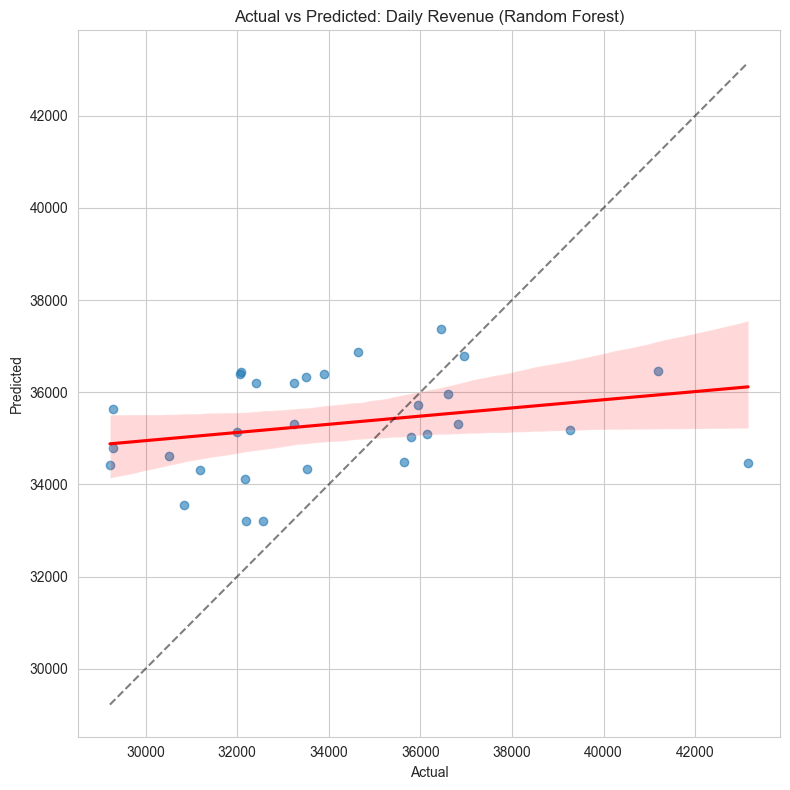

In [2]:
def get_predictions(target_name, model_name):
    series = daily[target_name].astype(float)
    d = pd.DataFrame({'y': series})
    for lag in (1, 2, 7, 14, 28): d[f'lag_{lag}'] = d['y'].shift(lag)
    d['roll_mean_7'] = d['y'].shift(1).rolling(7).mean()
    d['dow'] = d.index.dayofweek
    d = d.dropna()
    
    # Simple split (last 30 days for testing)
    train = d.iloc[:-30]
    test = d.iloc[-30:]
    
    if model_name == 'RandomForest':
        model = RandomForestRegressor(n_estimators=100, random_state=42)
    else:
        model = LinearRegression()
        
    model.fit(train.drop(columns=['y']), train['y'])
    preds = model.predict(test.drop(columns=['y']))
    return test['y'].values, preds

y_true, y_pred = get_predictions('daily_revenue', 'RandomForest')

plt.figure(figsize=(8, 8))
sns.regplot(x=y_true, y=y_pred, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], '--', color='black', alpha=0.5)
plt.title('Actual vs Predicted: Daily Revenue (Random Forest)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / '04c_scatter_actual_pred.png')
plt.show()

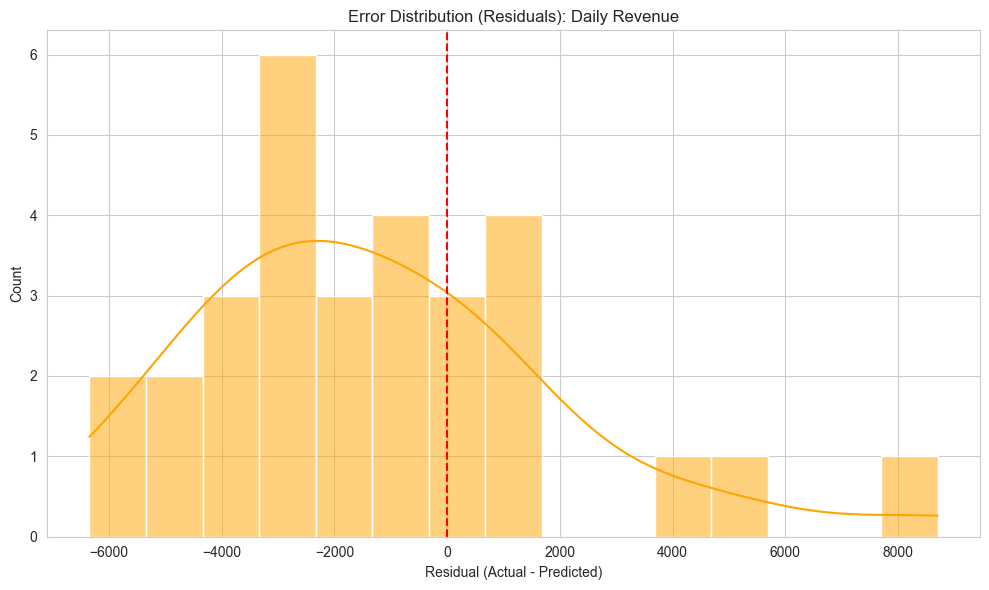

In [3]:
residuals = y_true - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=15, color='orange')
plt.axvline(0, color='red', linestyle='--')
plt.title('Error Distribution (Residuals): Daily Revenue')
plt.xlabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / '04c_residual_dist.png')
plt.show()

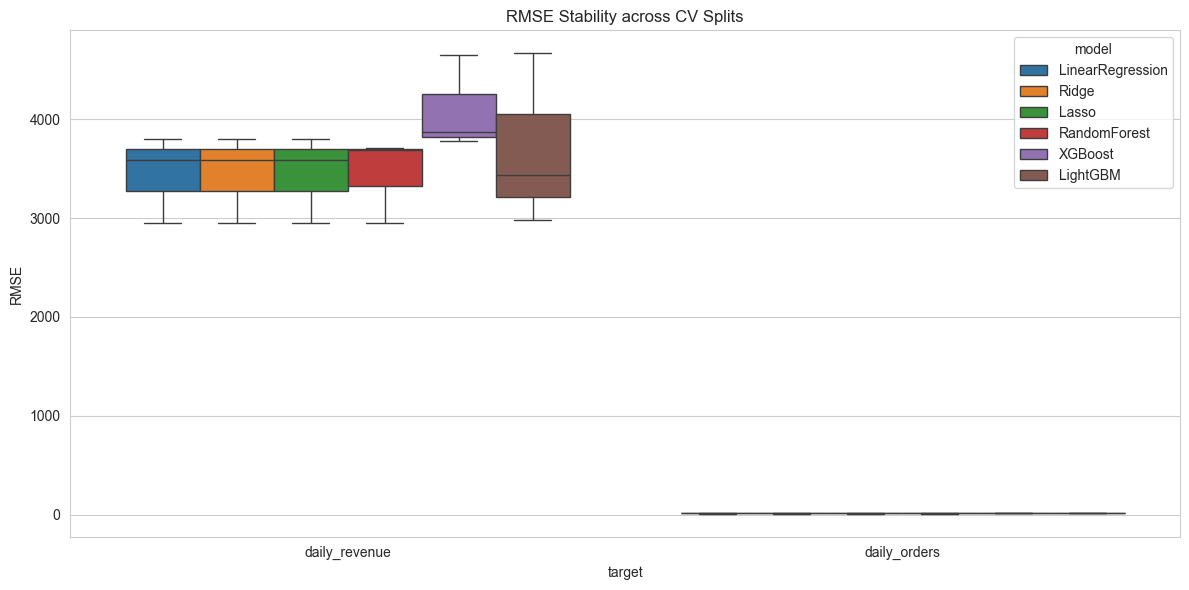

In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=metrics, x='target', y='RMSE', hue='model')
plt.title('RMSE Stability across CV Splits')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / '04c_cv_stability_boxplot.png')
plt.show()

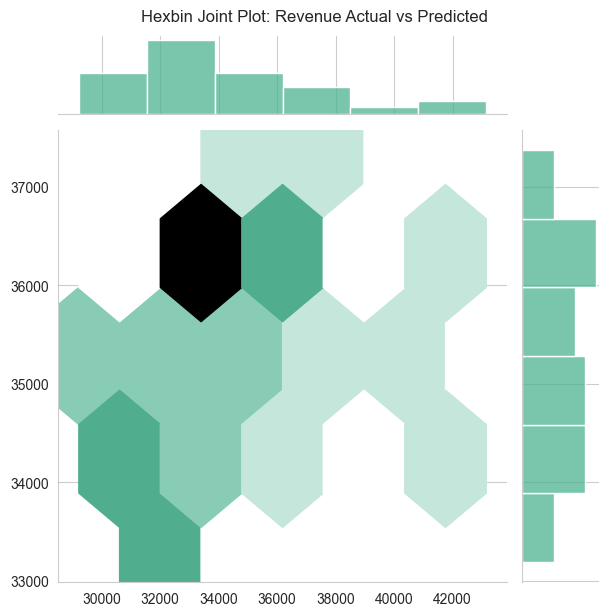

In [5]:
g = sns.jointplot(x=y_true, y=y_pred, kind="hex", color="#4CB391")
g.fig.suptitle('Hexbin Joint Plot: Revenue Actual vs Predicted', y=1.02)
plt.savefig(ARTIFACTS_DIR / '04c_joint_actual_pred.png')
plt.show()

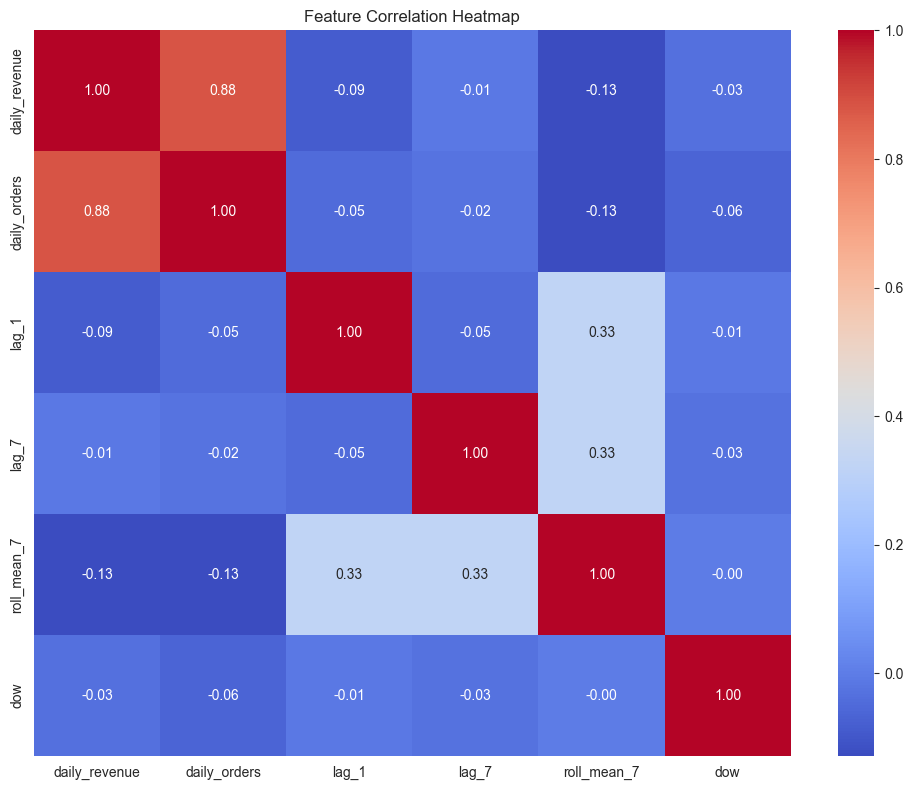

In [6]:
df_corr = daily[['daily_revenue', 'daily_orders']].copy()
df_corr['lag_1'] = df_corr['daily_revenue'].shift(1)
df_corr['lag_7'] = df_corr['daily_revenue'].shift(7)
df_corr['roll_mean_7'] = df_corr['daily_revenue'].shift(1).rolling(7).mean()
df_corr['dow'] = df_corr.index.dayofweek

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / '04c_correlation_heatmap.png')
plt.show()